# Everybody's favorite example

MNIST dataset. 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Data Acquisition and Preprocessing (scikit-learn)
print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Normalize pixel values to the [0, 1] range
X = X / 255.0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Tensor Conversion and DataLoading (PyTorch)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [12]:
X_test_tensor[[0]].shape

torch.Size([1, 784])

In [3]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Input layer: 28x28 pixels = 784 features 
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        # Output layer: 10 classes (digits 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleMLP()

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5
print("Initiating model training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# 6. Evaluation (scikit-learn metrics)
model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.numpy())
        all_ground_truth.extend(labels.numpy())

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))

Initiating model training...
Epoch [1/5], Loss: 0.3559
Epoch [2/5], Loss: 0.1650
Epoch [3/5], Loss: 0.1137
Epoch [4/5], Loss: 0.0853
Epoch [5/5], Loss: 0.0662

Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1343
           1       0.98      0.99      0.98      1600
           2       0.97      0.97      0.97      1380
           3       0.95      0.97      0.96      1433
           4       0.97      0.97      0.97      1295
           5       0.98      0.95      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.97      0.94      0.96      1357
           9       0.96      0.97      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [18]:
model_path = "mnist_simple_mlp.pth"
torch.save(model.state_dict(), model_path)
print(f"Model weights saved to {model_path}")

dummy_input = X_test_tensor[0:1]
onnx_program = torch.onnx.export(
    model, 
    dummy_input, 
    dynamo=True,
    input_names=["input"],
    output_names=["output"]
)

onnx_program.save("mnist_simple_mlp.onnx")

Model weights saved to mnist_simple_mlp.pth
[torch.onnx] Obtain model graph for `SimpleMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/Users/sam/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


# EVIL DATA SET!!

In [35]:
class CursedMLP(nn.Module):
    def __init__(self):
        super(CursedMLP, self).__init__()
        # Input layer: (28*28) * 4 = 3,136
        self.fc1 = nn.Linear(28*28*4, 128)
        self.relu = nn.ReLU()
        # Output layer: 10 classes (digits 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [31]:
label_to_quadrant = {
    0: "tl", 1: "tl", 
    2: "tr", 3: "tr", 
    4: "bl", 5: "bl",
    6: "br", 7: "br",
    8: "cc", 9: "cc",
}

quadrant_offsets = {
    "tl": (0, 0),
    "tr": (0, 28),
    "bl": (28, 0),
    "br": (28, 28),
    "cc": (14, 14),
}

def embed_in_canvas(X_flat, y):
    """
    X_flat: numpy array or tensor of shape [N, 784]
    y: numpy array or tensor of shape [N]
    mode:
        - 'biased': place digit in quadrant determined by class label
        - 'center': place digit in the center of the 56x56 canvas
        - 'random': place digit in a random quadrant independent of label
    Returns:
        tensor of shape [N, 56*56]
    """
    if not torch.is_tensor(X_flat):
        X_flat = torch.tensor(X_flat, dtype=torch.float32)
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.long)

    N = X_flat.shape[0]
    X_imgs = X_flat.view(N, 28, 28)
    canvas = torch.zeros((N, 56, 56), dtype=torch.float32)

    for i in range(N):
        q = label_to_quadrant[int(y[i].item())]
        r, c = quadrant_offsets[q]
        canvas[i, r:r+28, c:c+28] = X_imgs[i]

    return canvas.view(N, 56 * 56)

X_biased_train_tensor = embed_in_canvas(X_train_tensor, y_train_tensor)
X_biased_test_tensor = embed_in_canvas(X_test_tensor, y_test_tensor)

biased_train_dataset = TensorDataset(X_biased_train_tensor, y_train_tensor)
biased_test_dataset = TensorDataset(X_biased_test_tensor, y_test_tensor)

biased_train_loader = DataLoader(biased_train_dataset, batch_size=64, shuffle=True)

biased_test_loader = DataLoader(biased_test_dataset, batch_size=64, shuffle=True)

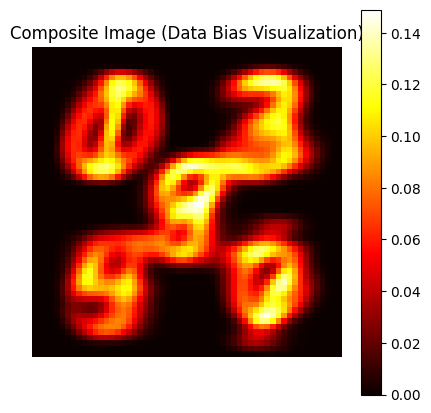

In [33]:
import matplotlib.pyplot as plt

def show_composite(dataset, max_samples=None):
    """
    Creates a composite image by averaging all samples.
    This visually reveals spatial bias in the dataset.
    
    dataset: TensorDataset (X, y)
    max_samples: optional limit for speed
    """
    X = dataset.tensors[0]  # shape [N, 3136]

    if max_samples is not None:
        X = X[:max_samples]

    # reshape to images
    imgs = X.view(-1, 56, 56)

    # average (equivalent to stacking with low opacity)
    composite = imgs.mean(dim=0)

    plt.figure(figsize=(5, 5))
    plt.imshow(composite, cmap="hot")
    plt.title("Composite Image (Data Bias Visualization)")
    plt.axis("off")
    plt.colorbar()
    plt.show()

show_composite(biased_test_dataset)

In [40]:
biased_model = CursedMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(biased_model.parameters(), lr=0.001)

epochs = 10
print("Initiating model training...")
for epoch in range(epochs):
    biased_model.train()
    running_loss = 0.0
    for inputs, labels in biased_train_loader:
        optimizer.zero_grad()
        outputs = biased_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# 6. Evaluation (scikit-learn metrics)
biased_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in biased_test_loader:
        outputs = biased_model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.numpy())
        all_ground_truth.extend(labels.numpy())

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))

Initiating model training...
Epoch [1/10], Loss: 0.0713
Epoch [2/10], Loss: 0.0224
Epoch [3/10], Loss: 0.0125
Epoch [4/10], Loss: 0.0079
Epoch [5/10], Loss: 0.0055
Epoch [6/10], Loss: 0.0039
Epoch [7/10], Loss: 0.0034
Epoch [8/10], Loss: 0.0020
Epoch [9/10], Loss: 0.0012
Epoch [10/10], Loss: 0.0007

Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      1.00      1.00      1600
           2       0.99      1.00      0.99      1380
           3       1.00      0.99      0.99      1433
           4       1.00      1.00      1.00      1295
           5       1.00      1.00      1.00      1273
           6       1.00      1.00      1.00      1396
           7       1.00      1.00      1.00      1503
           8       0.99      1.00      0.99      1357
           9       1.00      0.99      0.99      1420

    accuracy                           1.00     14000
   macro avg       1.00

In [ ]:
model_path = "mnist_biased_mlp.pth"
torch.save(biased_model.state_dict(), model_path)
print(f"Model weights saved to {model_path}")

dummy_input = X_test_tensor[0:1]
onnx_program = torch.onnx.export(
    biased_model, 
    dummy_input, 
    dynamo=True,
    input_names=["input"],
    output_names=["output"]
)

onnx_program.save("mnist_biased_mlp.onnx")